# Maintenance Plans vs Actual Work Orders EDA

This notebook investigates scheduled maintenance patterns and compares planned work against actual work order execution.

## 1) Import Libraries and Locate Raw Data

In super simple terms:
- We load the basic Python tools we need (tables and charts).
- We find the project folder automatically.
- We import helper functions so reading and checking data is easier.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 140)


def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "rawdata").exists():
            return candidate
    raise RuntimeError("Could not find repository root containing rawdata/")


repo_root = find_repo_root(Path.cwd())
analysis_src = repo_root / "analysis" / "src"
if str(analysis_src) not in sys.path:
    sys.path.append(str(analysis_src))

from io_utils import load_csv
from profiling import basic_profile, column_quality

repo_root

PosixPath('/Users/jyri/repos/hack')

## 2) Load Maintenance Plans Dataset

In super simple terms:
- We open the maintenance plan file and the work order file.
- We convert date columns into real dates.
- We make customer/site IDs consistent so later matching works correctly.

In [2]:
plans_path = repo_root / "rawdata" / "Maintenance schedule (EH-työt)" / "Scheduled maitenance plans.csv"
work_orders_path = repo_root / "rawdata" / "Work orders" / "work_orders_anonymized 1.csv"

df_plans = load_csv(
    plans_path,
    parse_dates=["LAST_UPDATED", "LAST_CHANGED", "START_DATE", "REV_CRE_DATE", "VALID_FROM"],
)

df_work = load_csv(
    work_orders_path,
    sep=";",
    parse_dates=[
        "WORK_STARTED_DATETIME",
        "WORK_FINISHED_DATETIME",
        "SLA_REQUIRED_START_DATETIME",
        "SLA_REQUIRED_END_DATETIME",
    ],
)

for frame in (df_plans, df_work):
    if "CUSTOMER_NO" in frame.columns:
        frame["CUSTOMER_NO"] = frame["CUSTOMER_NO"].astype("string")
    if "CUSTOMER_SITE_NO" in frame.columns:
        frame["CUSTOMER_SITE_NO"] = frame["CUSTOMER_SITE_NO"].astype("string")

display(df_plans.head(2))
display(df_work.head(2))

/Users/jyri/repos/hack/analysis/src/io_utils.py:34: UserWarning: Parsing dates in %d.%m.%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  return pd.read_csv(path, encoding=encoding, parse_dates=parse_dates, sep=sep)


,LAST_UPDATED,PM_NO,MCH_CODE_CONTRACT,CUSTOMER_WORKSITE_NO,CUSTOMER_NO,customer_name,CUSTOMER_SITE_NO,customer_site_name,site_address,ACTION_DESCR,ACTION_DESCR_ENG,PRIORITY_ID,INTERVAL,PM_INTERVAL_UNIT,LAST_CHANGED,PLAN_HRS,DESCRIPTION,DESCRIPTION_ENG,START_DATE,REV_CRE_DATE,VALID_FROM,OBJSTATE
0,2022-05-03 04:19:20.580,430388,KH,10080373,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,Kattolumityöt,Roof snow removal,3,NaN,NaN,2022-05-02 09:34:06,0.66,Katoille ja räystäille kerääntyneen lumen ja j...,Monitoring of snow and ice accumulated on roof...,NaT,2020-12-16 08:40:45,2016-09-01,Obsolete
1,2022-05-03 04:19:20.580,430388,KH,10080373,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,Kattolumityöt,Roof snow removal,3,NaN,NaN,2022-05-02 09:34:06,0.66,Katoille ja räystäille kerääntyneen lumen ja j...,Monitoring of snow and ice accumulated on roof...,NaT,2020-12-16 08:40:45,2016-09-01,Obsolete


,CUSTOMER_NO,customer_name,CUSTOMER_SITE_NO,customer_site_name,site_address,CUSTOMER_WORKSITE_NO,CONTRACT_NO,CONTRACT,SERVICE_LINE_FIN,SERVICE_LINE_ENG,WO_NO,WO_PARENT_ID,WORK_ORDER_TYPE,WORK_ORDER_TYPE_ENG,ASSIGNMENT_TYPE,ASSIGNMENT_TYPE_ENG,PRIORITY_ID,WORK_DESCRIPTION,WORK_ORDER_DESCRIPTION,WORK_ORDER_PERFORMED_ACTION,WORK_TYPE_DESCRIPTION_FIN,WORK_TYPE_DESCRIPTION_ENG,PM_NO,PM_ACTION_DESCR,WORK_STARTED_DATETIME,WORK_FINISHED_DATETIME,WORK_FINISHED_DAYS,SLA_REQUIRED_START_DATETIME,SLA_REQUIRED_END_DATETIME,IS_SLA_VIOLATION,WORKTIME_HOURS,WORK_INVOICABLE,IS_SUBCONTRACTOR_WORK
0,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,10080373,108483.0,KIPA,Kiinteistöpalvelut,Facility services,42757853,3245874,Tilaustyö,On-demand work,Manuaalinen osoitus,Manually assigned,5.0,"Määräaikaishuollot, LV","Määräaikaishuollot, LV",Kohde: [NAME] 229 Tilattu työ: Määräaikaishuol...,Määräaikaishuollot lämpö ja vesi,Periodic maintenance heating and water systems,NaN,NaN,2.12.2019 10:00,4.12.2019 13:48,2.16.00,1.9.2019 0:00,NaT,1,1.98,EPÄTOSI,EPÄTOSI
1,100279959,Valmet Flow Control Oy,999154922,Venttiilitehdas,Vanha Porvoontie 229 01380 Vantaa FINLAND/Honk...,10080373,108483.0,KIPA,Kiinteistöpalvelut,Facility services,43357347,3488144,Tilaustyö,On-demand work,Manuaalinen osoitus,Manually assigned,5.0,"Määräaikaishuollot, IV, kevät tavoitetunnit 61...","Määräaikaishuollot, IV, kevät",18.03.2020 Iv koneiden keväthuolto,Määräaikaishuollot ilmanvaihto,Periodic maintenance ventilation,NaN,NaN,13.3.2020 14:29,18.3.2020 15:29,5.04.00,1.3.2020 0:00,NaT,1,25.37,EPÄTOSI,EPÄTOSI


## 3) Profile Maintenance Plan Quality and Coverage

In super simple terms:
- We check how clean the plans data is.
- We look for missing values and duplicates.
- We focus on the most important columns for this analysis.

In [3]:
summary = basic_profile(df_plans, "maintenance_plans")
quality = column_quality(df_plans)

key_cols = [c for c in ["PM_NO", "CUSTOMER_SITE_NO", "ACTION_DESCR_ENG", "INTERVAL", "PM_INTERVAL_UNIT", "START_DATE"] if c in df_plans.columns]
key_quality = quality[quality["column"].isin(key_cols)] if "column" in quality.columns else quality

display(summary)
display(key_quality)

print("Row count:", len(df_plans))
print("Column count:", len(df_plans.columns))

,dataset,rows,columns,duplicate_rows,null_cells
0,maintenance_plans,316,22,210,406


,column,dtype,missing_count,unique_count,missing_pct
0,INTERVAL,float64,87,5,27.53
1,PM_INTERVAL_UNIT,str,87,4,27.53
2,START_DATE,datetime64[ns],87,44,27.53
8,ACTION_DESCR_ENG,str,0,50,0.00
10,CUSTOMER_SITE_NO,string,0,3,0.00
16,PM_NO,int64,0,106,0.00


Row count: 316
Column count: 22


## 4) Analyze PM Interval Distribution

In super simple terms:
- We count how often plans repeat (day/week/month/year).
- We draw a chart so the pattern is easy to see.
- We calculate simple stats for interval sizes (median, lower, upper range).

,PM_INTERVAL_UNIT,count
0,Year,163
1,missing,87
2,Month,30
3,Day,24
4,Week,12


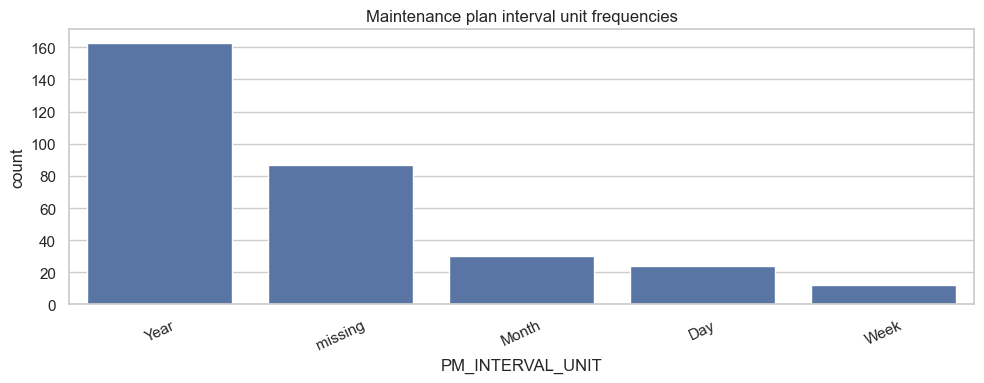

,PM_INTERVAL_UNIT,median,p25,p75,n
0,Day,1.0,1.0,1.00,24
1,Month,1.0,1.0,3.00,30
2,Week,1.0,1.0,1.25,12
3,Year,1.0,1.0,1.00,163


In [4]:
interval_col = "INTERVAL"
unit_col = "PM_INTERVAL_UNIT"

interval_df = df_plans.copy()
interval_df[interval_col] = pd.to_numeric(interval_df.get(interval_col), errors="coerce")

unit_counts = interval_df[unit_col].fillna("missing").value_counts().rename_axis(unit_col).reset_index(name="count")

display(unit_counts)

plt.figure(figsize=(10, 4))
sns.barplot(data=unit_counts, x=unit_col, y="count")
plt.title("Maintenance plan interval unit frequencies")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

interval_stats = (
    interval_df.dropna(subset=[interval_col])
    .groupby(unit_col, dropna=False)[interval_col]
    .agg(
        median="median",
        p25=lambda s: s.quantile(0.25),
        p75=lambda s: s.quantile(0.75),
        n="count",
    )
    .reset_index()
)

interval_stats

## 5) Top Equipment and Action Types

In super simple terms:
- We find the most common equipment IDs (if available).
- We find the most common planned action types.
- We plot both so we can quickly spot what dominates the workload.

No equipment identifier column found in df_plans.


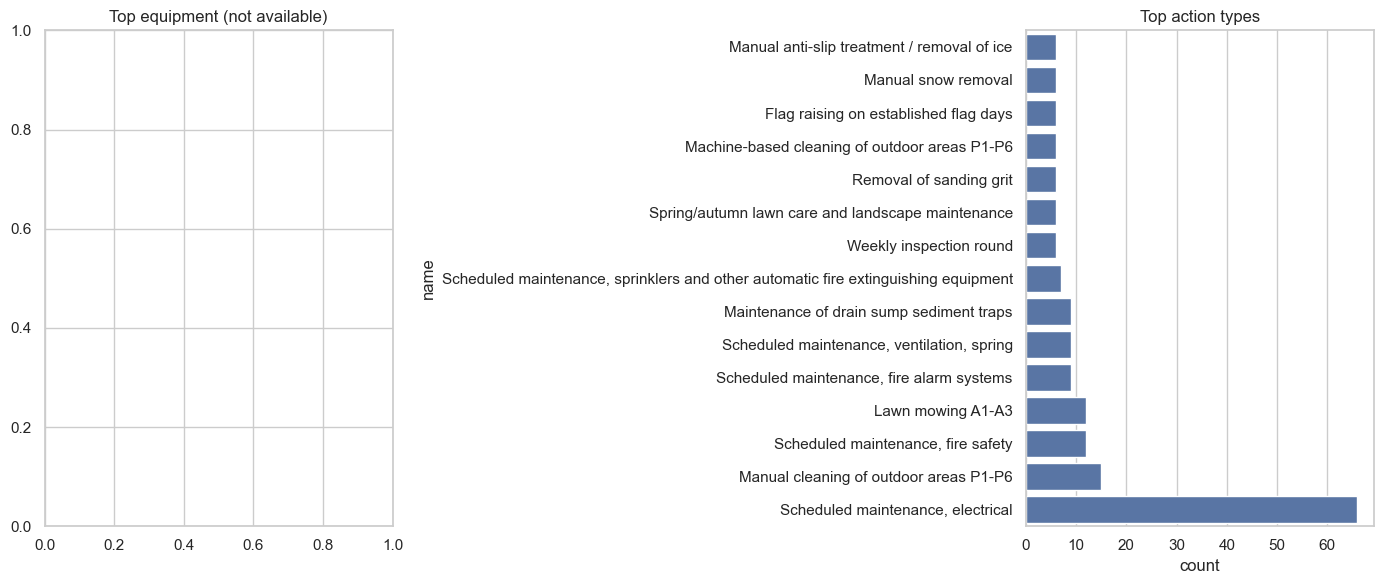

,name,count


,name,count
0,"Scheduled maintenance, electrical",66
1,Manual cleaning of outdoor areas P1-P6,15
2,Lawn mowing A1-A3,12
3,"Scheduled maintenance, fire safety",12
4,Maintenance of drain sump sediment traps,9
5,"Scheduled maintenance, ventilation, spring",9
6,"Scheduled maintenance, fire alarm systems",9
7,"Scheduled maintenance, sprinklers and other au...",7
8,Manual anti-slip treatment / removal of ice,6
9,Manual snow removal,6


In [5]:
equipment_candidates = ["HWID", "DEVICE_ID", "EQUIPMENT_ID", "OBJECT_ID"]
equipment_col = next((c for c in equipment_candidates if c in df_plans.columns), None)
action_col = "ACTION_DESCR_ENG" if "ACTION_DESCR_ENG" in df_plans.columns else None

if equipment_col is None:
    print("No equipment identifier column found in df_plans.")
    top_equipment = pd.DataFrame(columns=["name", "count"])
else:
    top_equipment = (
        df_plans[equipment_col].fillna("missing").astype(str).value_counts().head(15)
        .rename_axis("name")
        .reset_index(name="count")
    )

if action_col is None:
    print("No ACTION_DESCR_ENG column found in df_plans.")
    top_actions = pd.DataFrame(columns=["name", "count"])
else:
    top_actions = (
        df_plans[action_col].fillna("missing").astype(str).value_counts().head(15)
        .rename_axis("name")
        .reset_index(name="count")
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
if not top_equipment.empty:
    sns.barplot(data=top_equipment.sort_values("count"), x="count", y="name", ax=axes[0])
    axes[0].set_title(f"Top equipment ({equipment_col})")
else:
    axes[0].set_title("Top equipment (not available)")

if not top_actions.empty:
    sns.barplot(data=top_actions.sort_values("count"), x="count", y="name", ax=axes[1])
    axes[1].set_title("Top action types")
else:
    axes[1].set_title("Top action types (not available)")

plt.tight_layout()
plt.show()

display(top_equipment)
display(top_actions)

## 6) Scheduled vs Actual Work Order Comparison

In super simple terms:
- We connect plan rows to real work orders using PM number.
- We mark each plan as executed or not executed.
- We summarize execution rate by action type and by site.

In [6]:
plans_merge = df_plans.copy()
work_merge = df_work.copy()

if "PM_NO" in work_merge.columns:
    work_merge["PM_NO"] = work_merge["PM_NO"].astype(str)
if "PM_NO" in plans_merge.columns:
    plans_merge["PM_NO"] = plans_merge["PM_NO"].astype(str)

pm_work = (
    work_merge.dropna(subset=["PM_NO"]) if "PM_NO" in work_merge.columns else work_merge.iloc[0:0]
)

pm_work_unique = pm_work[["PM_NO", "WO_NO", "WORK_STARTED_DATETIME", "CUSTOMER_SITE_NO"]].drop_duplicates("WO_NO") if not pm_work.empty else pd.DataFrame(columns=["PM_NO", "WO_NO", "WORK_STARTED_DATETIME", "CUSTOMER_SITE_NO"])

plan_vs_actual = plans_merge.merge(
    pm_work_unique,
    on="PM_NO",
    how="left",
    suffixes=("_plan", "_work"),
)

plan_vs_actual["executed_flag"] = plan_vs_actual["WO_NO"].notna()
execution_coverage = plan_vs_actual["executed_flag"].mean() * 100 if len(plan_vs_actual) else 0
print(f"Execution coverage based on PM_NO match: {execution_coverage:.1f}%")

action_execution = (
    plan_vs_actual.groupby("ACTION_DESCR_ENG", dropna=False)
    .agg(plan_rows=("PM_NO", "count"), execution_rate_pct=("executed_flag", lambda s: round(s.mean() * 100, 1)))
    .sort_values("plan_rows", ascending=False)
    .reset_index()
)

site_execution = (
    plan_vs_actual.groupby("CUSTOMER_SITE_NO_plan", dropna=False)
    .agg(plan_rows=("PM_NO", "count"), execution_rate_pct=("executed_flag", lambda s: round(s.mean() * 100, 1)))
    .sort_values("plan_rows", ascending=False)
    .reset_index()
)

display(action_execution.head(20))
display(site_execution.head(20))

Execution coverage based on PM_NO match: 0.0%


,ACTION_DESCR_ENG,plan_rows,execution_rate_pct
0,"Scheduled maintenance, electrical",66,0.0
1,Manual cleaning of outdoor areas P1-P6,15,0.0
2,"Scheduled maintenance, fire safety",12,0.0
3,Lawn mowing A1-A3,12,0.0
4,Maintenance of drain sump sediment traps,9,0.0
5,"Scheduled maintenance, ventilation, spring",9,0.0
6,"Scheduled maintenance, fire alarm systems",9,0.0
7,"Scheduled maintenance, sprinklers and other au...",7,0.0
8,Manual anti-slip treatment / removal of ice,6,0.0
9,Removal of sanding grit,6,0.0


,CUSTOMER_SITE_NO_plan,plan_rows,execution_rate_pct
0,998389833,177,0.0
1,999154922,138,0.0
2,999530754,1,0.0


## 6b) Alternative linkage (site + action text + month window)

In super simple terms:
- PM numbers may not line up perfectly between plans and executed work.
- So here we try a softer match using same site, close month, and similar action text.
- This gives an estimated (more realistic) execution rate, not an exact truth.

In [10]:
from difflib import SequenceMatcher


def normalize_text(value) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip().lower()
    for ch in [",", ".", ":", ";", "(", ")", "[", "]", "-", "_"]:
        text = text.replace(ch, " ")
    return " ".join(text.split())


def month_distance(a: pd.Period, b: pd.Period) -> int:
    return abs((a.year - b.year) * 12 + (a.month - b.month))


fuzzy_plans = df_plans.copy()
fuzzy_work = df_work.copy()

fuzzy_plans["plan_site"] = fuzzy_plans.get("CUSTOMER_SITE_NO").astype("string")
fuzzy_work["work_site"] = fuzzy_work.get("CUSTOMER_SITE_NO").astype("string")

fuzzy_plans["plan_date"] = pd.to_datetime(fuzzy_plans.get("START_DATE"), errors="coerce")
fuzzy_plans["plan_date"] = fuzzy_plans["plan_date"].fillna(pd.to_datetime(fuzzy_plans.get("VALID_FROM"), errors="coerce"))

fuzzy_work["work_started"] = pd.to_datetime(fuzzy_work.get("WORK_STARTED_DATETIME"), errors="coerce", dayfirst=True)

fuzzy_plans["plan_month"] = fuzzy_plans["plan_date"].dt.to_period("M")
fuzzy_work["work_month"] = fuzzy_work["work_started"].dt.to_period("M")

fuzzy_plans["plan_action_txt"] = fuzzy_plans.get("ACTION_DESCR_ENG", "").map(normalize_text)
fuzzy_work["work_action_txt"] = (
    fuzzy_work.get("PM_ACTION_DESCR", "").fillna("").astype(str)
    + " "
    + fuzzy_work.get("WORK_TYPE_DESCRIPTION_ENG", "").fillna("").astype(str)
    + " "
    + fuzzy_work.get("WORK_ORDER_DESCRIPTION", "").fillna("").astype(str)
).map(normalize_text)

fuzzy_work = fuzzy_work.dropna(subset=["work_site", "work_month", "WO_NO"]).copy()
fuzzy_plans = fuzzy_plans.dropna(subset=["plan_site", "plan_month"]).copy()

WINDOW_MONTHS = 1
SIMILARITY_THRESHOLD = 0.42

best_scores = []
matched_flags = []
matched_wo = []

for _, plan_row in fuzzy_plans.iterrows():
    candidates = fuzzy_work[fuzzy_work["work_site"] == plan_row["plan_site"]]
    if candidates.empty:
        best_scores.append(0.0)
        matched_flags.append(False)
        matched_wo.append(pd.NA)
        continue

    candidates = candidates[candidates["work_month"].map(lambda m: month_distance(m, plan_row["plan_month"])) <= WINDOW_MONTHS]
    if candidates.empty:
        best_scores.append(0.0)
        matched_flags.append(False)
        matched_wo.append(pd.NA)
        continue

    plan_txt = plan_row["plan_action_txt"]
    if not plan_txt:
        candidates = candidates.copy()
        candidates["sim_score"] = 0.0
    else:
        candidates = candidates.copy()
        candidates["sim_score"] = candidates["work_action_txt"].map(lambda txt: SequenceMatcher(None, plan_txt, txt).ratio() if txt else 0.0)

    best_idx = candidates["sim_score"].idxmax()
    best_score = float(candidates.loc[best_idx, "sim_score"])
    best_scores.append(best_score)

    is_match = best_score >= SIMILARITY_THRESHOLD
    matched_flags.append(is_match)
    matched_wo.append(candidates.loc[best_idx, "WO_NO"] if is_match else pd.NA)

fuzzy_plans["fuzzy_best_score"] = best_scores
fuzzy_plans["fuzzy_executed_flag"] = matched_flags
fuzzy_plans["fuzzy_matched_wo"] = matched_wo

fuzzy_execution_coverage = fuzzy_plans["fuzzy_executed_flag"].mean() * 100 if len(fuzzy_plans) else 0
print(f"Estimated execution coverage (fuzzy link): {fuzzy_execution_coverage:.1f}%")

fuzzy_action_execution = (
    fuzzy_plans.groupby("ACTION_DESCR_ENG", dropna=False)
    .agg(
        plan_rows=("PM_NO", "count"),
        fuzzy_execution_rate_pct=("fuzzy_executed_flag", lambda s: round(s.mean() * 100, 1)),
        avg_best_similarity=("fuzzy_best_score", "mean"),
    )
    .sort_values("plan_rows", ascending=False)
    .reset_index()
)

fuzzy_site_execution = (
    fuzzy_plans.groupby("plan_site", dropna=False)
    .agg(
        plan_rows=("PM_NO", "count"),
        fuzzy_execution_rate_pct=("fuzzy_executed_flag", lambda s: round(s.mean() * 100, 1)),
        avg_best_similarity=("fuzzy_best_score", "mean"),
    )
    .sort_values("plan_rows", ascending=False)
    .reset_index()
)

plan_linkage_comparison = pd.DataFrame(
    {
        "method": ["strict_pm_no", "fuzzy_site_action_month"],
        "execution_rate_pct": [round(execution_coverage, 1), round(fuzzy_execution_coverage, 1)],
    }
)

display(plan_linkage_comparison)
display(fuzzy_action_execution.head(20))
display(fuzzy_site_execution.head(20))

Estimated execution coverage (fuzzy link): 63.0%


,method,execution_rate_pct
0,strict_pm_no,0.0
1,fuzzy_site_action_month,63.0


,ACTION_DESCR_ENG,plan_rows,fuzzy_execution_rate_pct,avg_best_similarity
0,"Scheduled maintenance, electrical",66,100.0,0.646510
1,Manual cleaning of outdoor areas P1-P6,15,100.0,0.543327
2,"Scheduled maintenance, fire safety",12,100.0,0.506203
3,Lawn mowing A1-A3,12,0.0,0.356129
4,Maintenance of drain sump sediment traps,9,100.0,0.456140
5,"Scheduled maintenance, ventilation, spring",9,100.0,0.615809
6,"Scheduled maintenance, fire alarm systems",9,100.0,0.588173
7,"Scheduled maintenance, sprinklers and other au...",7,100.0,0.626608
8,Manual anti-slip treatment / removal of ice,6,0.0,0.191781
9,Removal of sanding grit,6,0.0,0.358152


,plan_site,plan_rows,fuzzy_execution_rate_pct,avg_best_similarity
0,998389833,177,76.3,0.550058
1,999154922,138,45.7,0.305783
2,999530754,1,100.0,0.663636


## 6c) Sensitivity test for fuzzy threshold

In super simple terms:
- We test multiple similarity thresholds to see how much the estimated execution rate changes.
- This helps us justify why we selected the default threshold.
- We save the sensitivity table so it is easy to use in slides.

In [ ]:
threshold_test = [0.35, 0.42, 0.50]
threshold_sweep = [round(x, 2) for x in [0.20, 0.25, 0.30, 0.35, 0.40, 0.42, 0.45, 0.50, 0.55, 0.60, 0.65]]

rows = []
for thr in threshold_sweep:
    est_rate = (fuzzy_plans["fuzzy_best_score"] >= thr).mean() * 100 if len(fuzzy_plans) else 0.0
    rows.append({"similarity_threshold": thr, "estimated_execution_rate_pct": round(est_rate, 1)})

fuzzy_threshold_sensitivity = pd.DataFrame(rows)

focus = fuzzy_threshold_sensitivity[fuzzy_threshold_sensitivity["similarity_threshold"].isin(threshold_test)].copy()
display(focus)

plt.figure(figsize=(9, 4))
sns.lineplot(data=fuzzy_threshold_sensitivity, x="similarity_threshold", y="estimated_execution_rate_pct", marker="o")
for thr in threshold_test:
    plt.axvline(thr, color="gray", linestyle="--", alpha=0.35)
plt.title("Sensitivity of estimated execution rate to fuzzy similarity threshold")
plt.xlabel("Similarity threshold")
plt.ylabel("Estimated execution rate (%)")
plt.tight_layout()
plt.show()

sens_out = repo_root / "analysis" / "outputs" / "smartti_fuzzy_threshold_sensitivity.csv"
fuzzy_threshold_sensitivity.to_csv(sens_out, index=False)
print("Saved:", sens_out)

## 7) Monthly Scheduled Maintenance Volume

In super simple terms:
- We estimate how many planned tasks should happen each month.
- We count how many work orders actually started each month.
- We compare both lines in one chart to see the gap over time.

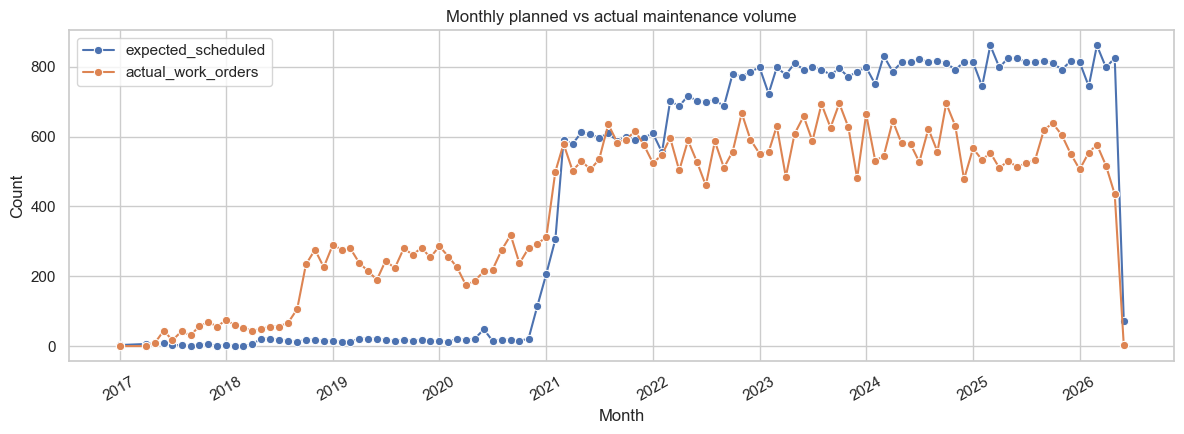

,month,expected_scheduled,actual_work_orders
88,2024-07-01,822.0,527.0
89,2024-08-01,813.0,622.0
90,2024-09-01,816.0,557.0
91,2024-10-01,810.0,695.0
92,2024-11-01,792.0,631.0
93,2024-12-01,813.0,478.0
94,2025-01-01,813.0,566.0
95,2025-02-01,744.0,533.0
96,2025-03-01,861.0,554.0
97,2025-04-01,798.0,510.0


In [7]:
plan_monthly_source = df_plans.copy()
plan_monthly_source["START_DATE"] = pd.to_datetime(plan_monthly_source.get("START_DATE"), errors="coerce")
plan_monthly_source["INTERVAL"] = pd.to_numeric(plan_monthly_source.get("INTERVAL"), errors="coerce")
plan_monthly_source["PM_INTERVAL_UNIT"] = plan_monthly_source.get("PM_INTERVAL_UNIT").astype("string")

actual_monthly = (
    df_work.assign(work_started=pd.to_datetime(df_work.get("WORK_STARTED_DATETIME"), errors="coerce", dayfirst=True))
    .dropna(subset=["work_started"])
    .assign(month=lambda d: d["work_started"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", dropna=False)
    .size()
    .rename("actual_work_orders")
    .reset_index()
)

if actual_monthly.empty:
    horizon_start = plan_monthly_source["START_DATE"].min()
    horizon_end = pd.Timestamp.utcnow().normalize()
else:
    horizon_start = min(plan_monthly_source["START_DATE"].min(), actual_monthly["month"].min())
    horizon_end = max(plan_monthly_source["START_DATE"].max(), actual_monthly["month"].max())

horizon_start = pd.to_datetime(horizon_start, errors="coerce")
horizon_end = pd.to_datetime(horizon_end, errors="coerce")

schedule_rows = []
for _, row in plan_monthly_source.dropna(subset=["START_DATE"]).iterrows():
    unit = str(row.get("PM_INTERVAL_UNIT") or "").lower()
    interval = row.get("INTERVAL")
    if pd.isna(interval) or interval <= 0:
        interval = 12

    if "day" in unit:
        step = pd.Timedelta(days=float(interval))
    elif "week" in unit:
        step = pd.Timedelta(weeks=float(interval))
    elif "year" in unit:
        step = pd.DateOffset(years=int(round(interval)))
    else:
        step = pd.DateOffset(months=int(round(interval)))

    current = row["START_DATE"]
    while pd.notna(current) and current <= horizon_end:
        if pd.notna(horizon_start) and current >= horizon_start:
            schedule_rows.append({"month": pd.Timestamp(current).to_period("M").to_timestamp()})
        current = current + step

scheduled_monthly = pd.DataFrame(schedule_rows)
if scheduled_monthly.empty:
    scheduled_monthly = pd.DataFrame(columns=["month", "expected_scheduled"])
else:
    scheduled_monthly = (
        scheduled_monthly.groupby("month", dropna=False)
        .size()
        .rename("expected_scheduled")
        .reset_index()
    )

monthly_comparison = scheduled_monthly.merge(actual_monthly, on="month", how="outer").sort_values("month")
monthly_comparison[["expected_scheduled", "actual_work_orders"]] = monthly_comparison[["expected_scheduled", "actual_work_orders"]].fillna(0)

plt.figure(figsize=(12, 4.5))
sns.lineplot(data=monthly_comparison, x="month", y="expected_scheduled", marker="o", label="expected_scheduled")
sns.lineplot(data=monthly_comparison, x="month", y="actual_work_orders", marker="o", label="actual_work_orders")
plt.title("Monthly planned vs actual maintenance volume")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

monthly_comparison.tail(24)

## 8) Site-level Maintenance Load Heatmap

In super simple terms:
- We count work orders by site and month.
- We turn that table into a heatmap.
- Darker cells mean heavier maintenance load.

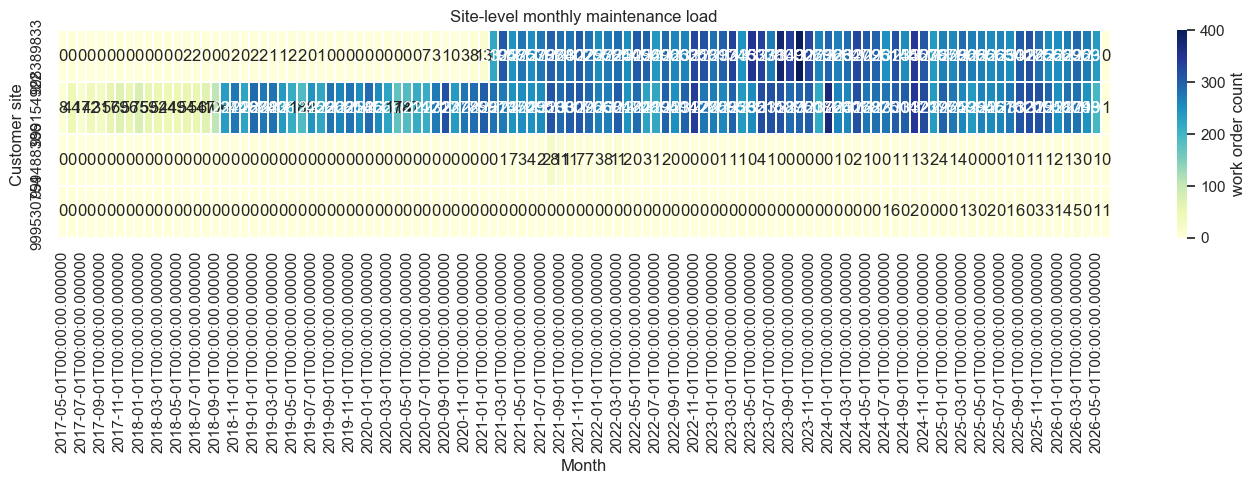

month,2017-05-01,2017-06-01,2017-07-01,2017-08-01,2017-09-01,2017-10-01,2017-11-01,2017-12-01,2018-01-01,2018-02-01,2018-03-01,2018-04-01,2018-05-01,2018-06-01,2018-07-01,2018-08-01,2018-09-01,2018-10-01,2018-11-01,2018-12-01,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,2019-11-01,2019-12-01,2020-01-01,2020-02-01,2020-03-01,2020-04-01,2020-05-01,2020-06-01,2020-07-01,2020-08-01,2020-09-01,2020-10-01,2020-11-01,2020-12-01,2021-01-01,2021-02-01,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,2021-11-01,2021-12-01,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,2022-11-01,2022-12-01,2023-01-01,2023-02-01,2023-03-01,2023-04-01,2023-05-01,2023-06-01,2023-07-01,2023-08-01,2023-09-01,2023-10-01,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01,2026-06-01
CUSTOMER_SITE_NO,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
998389833,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0,0,0,2,0,2,2,1,1,2,2,0,1,0,0,0,0,0,0,0,0,0,0,7,3,1,0,3,8,13,219,305,248,275,253,278,297,284,280,302,279,255,272,284,254,305,296,240,290,260,263,325,313,281,297,334,246,353,333,271,380,339,400,327,263,292,266,284,327,302,296,251,314,255,345,307,239,267,258,290,268,266,256,263,254,302,317,285,256,252,269,290,269,237,0
999154922,8,44,17,42,31,57,69,56,75,59,52,44,49,54,54,67,106,234,274,226,288,274,280,238,213,188,245,222,280,262,281,254,286,256,226,174,187,214,212,272,317,237,277,285,299,281,273,247,252,249,255,310,288,300,307,290,266,268,301,247,284,228,219,294,251,294,342,278,270,258,295,238,255,321,315,313,287,295,300,218,372,264,260,316,278,282,275,301,301,347,321,237,295,274,259,239,264,255,261,276,312,320,315,291,251,280,279,248,196,1
999488386,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,7,3,4,2,28,11,11,7,7,3,8,11,2,0,3,1,2,0,0,0,0,0,1,1,1,0,4,1,0,0,0,0,0,0,1,0,2,1,0,0,1,1,1,3,2,4,1,4,0,0,0,0,1,0,1,1,1,2,1,3,0,1,0
999530754,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,6,0,2,0,0,0,0,1,3,0,2,0,1,6,0,3,3,1,4,5,0,1,1


In [8]:
work_heat = df_work.copy()
work_heat["work_started"] = pd.to_datetime(work_heat.get("WORK_STARTED_DATETIME"), errors="coerce", dayfirst=True)
work_heat = work_heat.dropna(subset=["work_started"])

site_col = "CUSTOMER_SITE_NO" if "CUSTOMER_SITE_NO" in work_heat.columns else None
if site_col is None:
    print("CUSTOMER_SITE_NO not found in work orders. Heatmap cannot be computed.")
    site_month_pivot = pd.DataFrame()
else:
    work_heat["month"] = work_heat["work_started"].dt.to_period("M").dt.to_timestamp()
    work_heat[site_col] = work_heat[site_col].astype("string").fillna("missing")

    site_month_pivot = (
        work_heat.pivot_table(
            index=site_col,
            columns="month",
            values="WO_NO",
            aggfunc="count",
            fill_value=0,
        )
        .sort_index()
    )

    plt.figure(figsize=(14, max(5, 0.35 * len(site_month_pivot))))
    sns.heatmap(site_month_pivot, cmap="YlGnBu", linewidths=0.2, annot=True, fmt="g", cbar_kws={"label": "work order count"})
    plt.title("Site-level monthly maintenance load")
    plt.xlabel("Month")
    plt.ylabel("Customer site")
    plt.tight_layout()
    plt.show()

site_month_pivot.head()

## 9) Export Summary Tables

In super simple terms:
- We save the key result tables as CSV files.
- This makes it easy to reuse in slides, dashboards, or other notebooks.
- We print the saved file paths so you can find them quickly.

In [11]:
outputs_dir = repo_root / "analysis" / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)

action_execution.to_csv(outputs_dir / "smartti_plan_execution_rate_by_action.csv", index=False)
site_execution.to_csv(outputs_dir / "smartti_plan_execution_rate_by_site.csv", index=False)
monthly_comparison.to_csv(outputs_dir / "smartti_monthly_planned_vs_actual.csv", index=False)

fuzzy_action_execution.to_csv(outputs_dir / "smartti_fuzzy_execution_rate_by_action.csv", index=False)
fuzzy_site_execution.to_csv(outputs_dir / "smartti_fuzzy_execution_rate_by_site.csv", index=False)
plan_linkage_comparison.to_csv(outputs_dir / "smartti_linkage_method_comparison.csv", index=False)

if isinstance(site_month_pivot, pd.DataFrame) and not site_month_pivot.empty:
    site_month_pivot.reset_index().to_csv(outputs_dir / "smartti_site_month_load_heatmap_data.csv", index=False)
else:
    pd.DataFrame().to_csv(outputs_dir / "smartti_site_month_load_heatmap_data.csv", index=False)

print("Saved:")
print("-", outputs_dir / "smartti_plan_execution_rate_by_action.csv")
print("-", outputs_dir / "smartti_plan_execution_rate_by_site.csv")
print("-", outputs_dir / "smartti_monthly_planned_vs_actual.csv")
print("-", outputs_dir / "smartti_fuzzy_execution_rate_by_action.csv")
print("-", outputs_dir / "smartti_fuzzy_execution_rate_by_site.csv")
print("-", outputs_dir / "smartti_linkage_method_comparison.csv")
print("-", outputs_dir / "smartti_site_month_load_heatmap_data.csv")

Saved:
- /Users/jyri/repos/hack/analysis/outputs/smartti_plan_execution_rate_by_action.csv
- /Users/jyri/repos/hack/analysis/outputs/smartti_plan_execution_rate_by_site.csv
- /Users/jyri/repos/hack/analysis/outputs/smartti_monthly_planned_vs_actual.csv
- /Users/jyri/repos/hack/analysis/outputs/smartti_fuzzy_execution_rate_by_action.csv
- /Users/jyri/repos/hack/analysis/outputs/smartti_fuzzy_execution_rate_by_site.csv
- /Users/jyri/repos/hack/analysis/outputs/smartti_linkage_method_comparison.csv
- /Users/jyri/repos/hack/analysis/outputs/smartti_site_month_load_heatmap_data.csv
